#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Data collection and data cleaning

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/ine-rmotr-curriculum/FreeCodeCamp-Pandas-Real-Life-Example/refs/heads/master/data/sales_data.csv')
df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


In [3]:
df.shape

(113036, 18)

there are 113036 rows and 18 columns( features )

In [4]:
df.columns

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [7]:
df.columns=df.columns.str.lower()

In [9]:
# as the data type of date column is object we msut convert it into datetime

df['date']=pd.to_datetime(df['date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              113036 non-null  datetime64[ns]
 1   day               113036 non-null  int64         
 2   month             113036 non-null  object        
 3   year              113036 non-null  int64         
 4   customer_age      113036 non-null  int64         
 5   age_group         113036 non-null  object        
 6   customer_gender   113036 non-null  object        
 7   country           113036 non-null  object        
 8   state             113036 non-null  object        
 9   product_category  113036 non-null  object        
 10  sub_category      113036 non-null  object        
 11  product           113036 non-null  object        
 12  order_quantity    113036 non-null  int64         
 13  unit_cost         113036 non-null  int64         
 14  unit

In [11]:
df.isnull().sum()

date                0
day                 0
month               0
year                0
customer_age        0
age_group           0
customer_gender     0
country             0
state               0
product_category    0
sub_category        0
product             0
order_quantity      0
unit_cost           0
unit_price          0
profit              0
cost                0
revenue             0
dtype: int64

there is no missing value present in the dataset. if it is then we must fill those missing values using df.fillna

In [ ]:
df.duplicated().sum()

np.int64(1000)

as there are these many rows same we must drop these rows

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
# roi means how much profit you made comapred to how much you spent fro creation of that product

df['roi']=(df['profit']/df['cost'])*100
df.head(2)

,date,day,month,year,customer_age,age_group,customer_gender,country,state,product_category,sub_category,product,order_quantity,unit_cost,unit_price,profit,cost,revenue,roi
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,163.888889
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,163.888889


In [132]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['month',
 'age_group',
 'customer_gender',
 'country',
 'state',
 'product_category',
 'sub_category',
 'product']

##### unique values of categorical columns

In [135]:
for i in cat_cols:
    print(df[i].unique())
    print("-"*20)
    print()

['November' 'March' 'May' 'February' 'July' 'August' 'September' 'January'
 'December' 'June' 'October' 'April']
--------------------

['Youth (<25)' 'Adults (35-64)' 'Young Adults (25-34)' 'Seniors (64+)']
--------------------

['M' 'F']
--------------------

['Canada' 'Australia' 'United States' 'Germany' 'France' 'United Kingdom']
--------------------

['British Columbia' 'New South Wales' 'Victoria' 'Oregon' 'California'
 'Saarland' 'Seine Saint Denis' 'Moselle' 'Queensland' 'England' 'Nord'
 'Washington' 'Hessen' 'Nordrhein-Westfalen' 'Hamburg' 'Loir et Cher'
 'Kentucky' 'Seine (Paris)' 'South Australia' 'Loiret' 'Alberta' 'Bayern'
 'Hauts de Seine' 'Yveline' 'Essonne' "Val d'Oise" 'Tasmania'
 'Seine et Marne' 'Val de Marne' 'Pas de Calais' 'Charente-Maritime'
 'Garonne (Haute)' 'Brandenburg' 'Texas' 'New York' 'Florida' 'Somme'
 'Illinois' 'South Carolina' 'North Carolina' 'Georgia' 'Virginia' 'Ohio'
 'Ontario' 'Wyoming' 'Missouri' 'Montana' 'Utah' 'Minnesota' 'Mississippi'
 'Mas

##### Data Distribution

In [136]:
num_cols=[i for i in df.columns if df[i].dtypes!='O']
num_cols

['date',
 'day',
 'year',
 'customer_age',
 'order_quantity',
 'unit_cost',
 'unit_price',
 'profit',
 'cost',
 'revenue',
 'roi']

In [140]:
type(num_cols)

list

In [142]:
# to remove elements from the list remove()
for col in ['date','day','year']:
    if col in num_cols:
        num_cols.remove(col)
num_cols

['customer_age',
 'order_quantity',
 'unit_cost',
 'unit_price',
 'profit',
 'cost',
 'revenue',
 'roi']

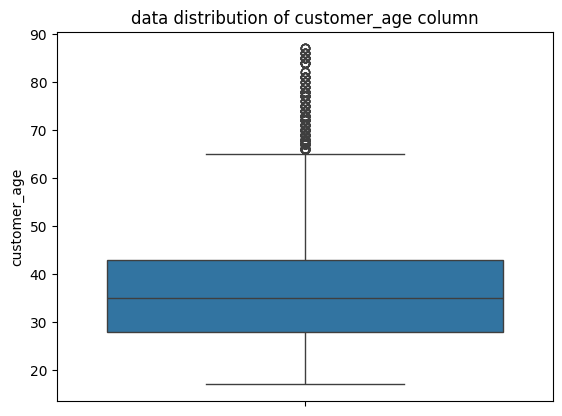

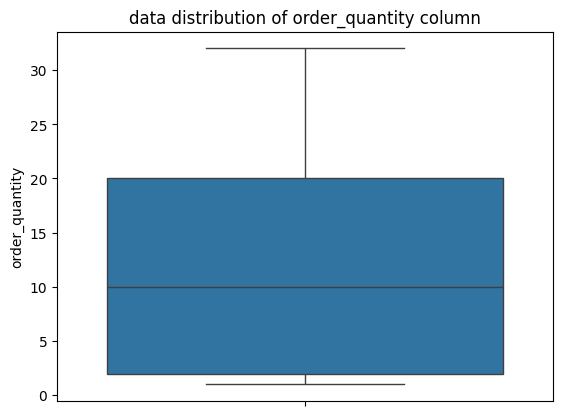

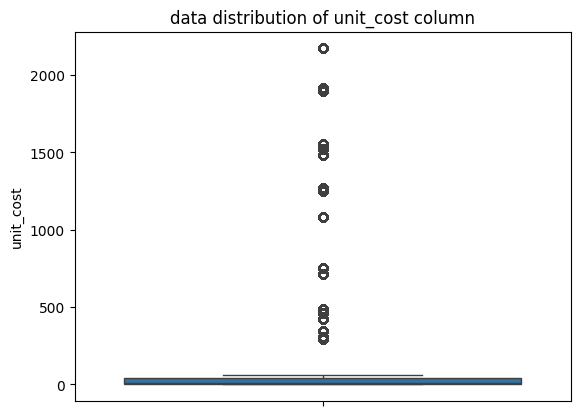

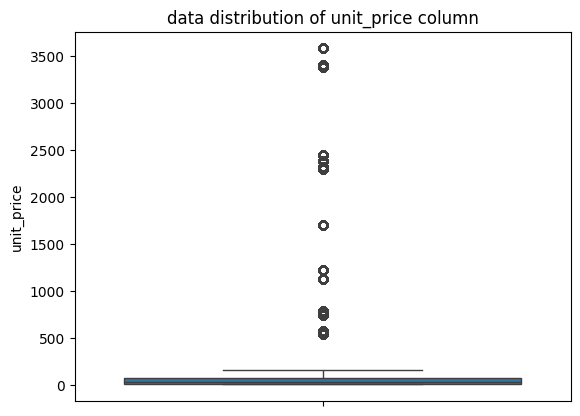

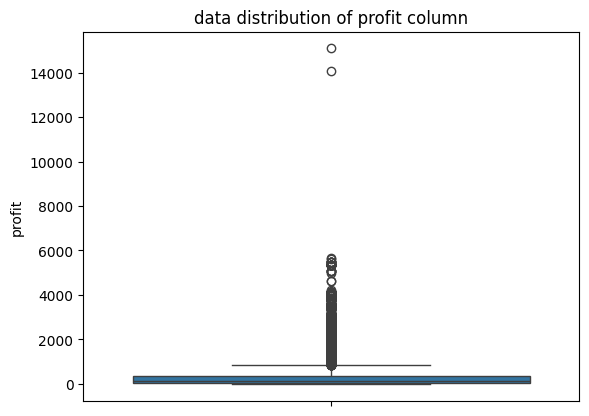

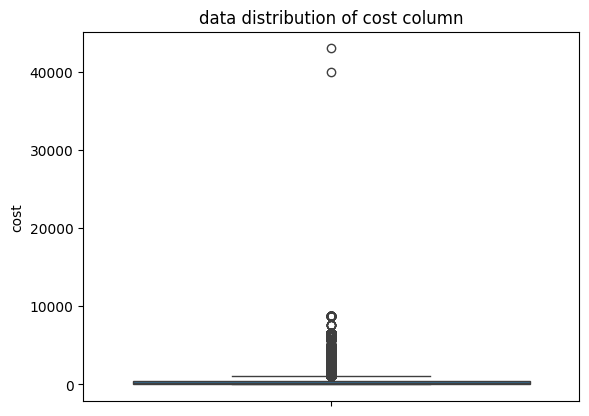

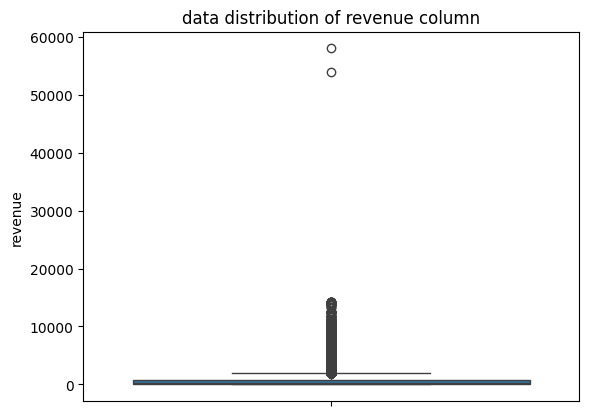

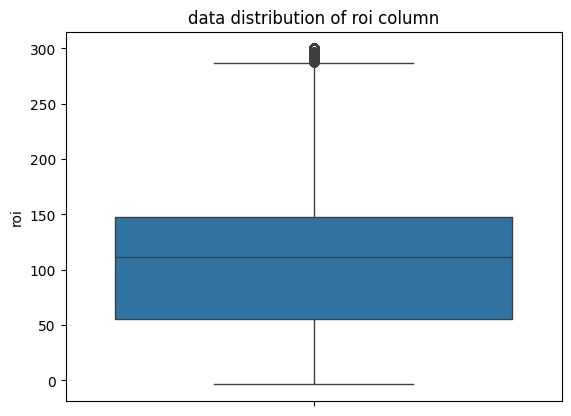

In [143]:
for i in num_cols:
    sns.boxplot(df[i])
    plt.title(f"data distribution of {i} column")
    plt.show()

##### Total Revenue generated

In [27]:
print("total revenue: ",df['revenue'].sum())

total revenue:  84826772


##### Total Profit Earned

In [28]:
print("total profit earned: ",df['profit'].sum())

total profit earned:  32046239


##### Total Orders were placed

In [32]:
print("total orders: ",df.shape[0])

total orders:  112036


##### Product Categories

In [35]:
df['product_category'].unique()

array(['Accessories', 'Clothing', 'Bikes'], dtype=object)

##### Countries present in the dataset

In [36]:
df['country'].unique()

array(['Canada', 'Australia', 'United States', 'Germany', 'France',
       'United Kingdom'], dtype=object)

##### Sales by year

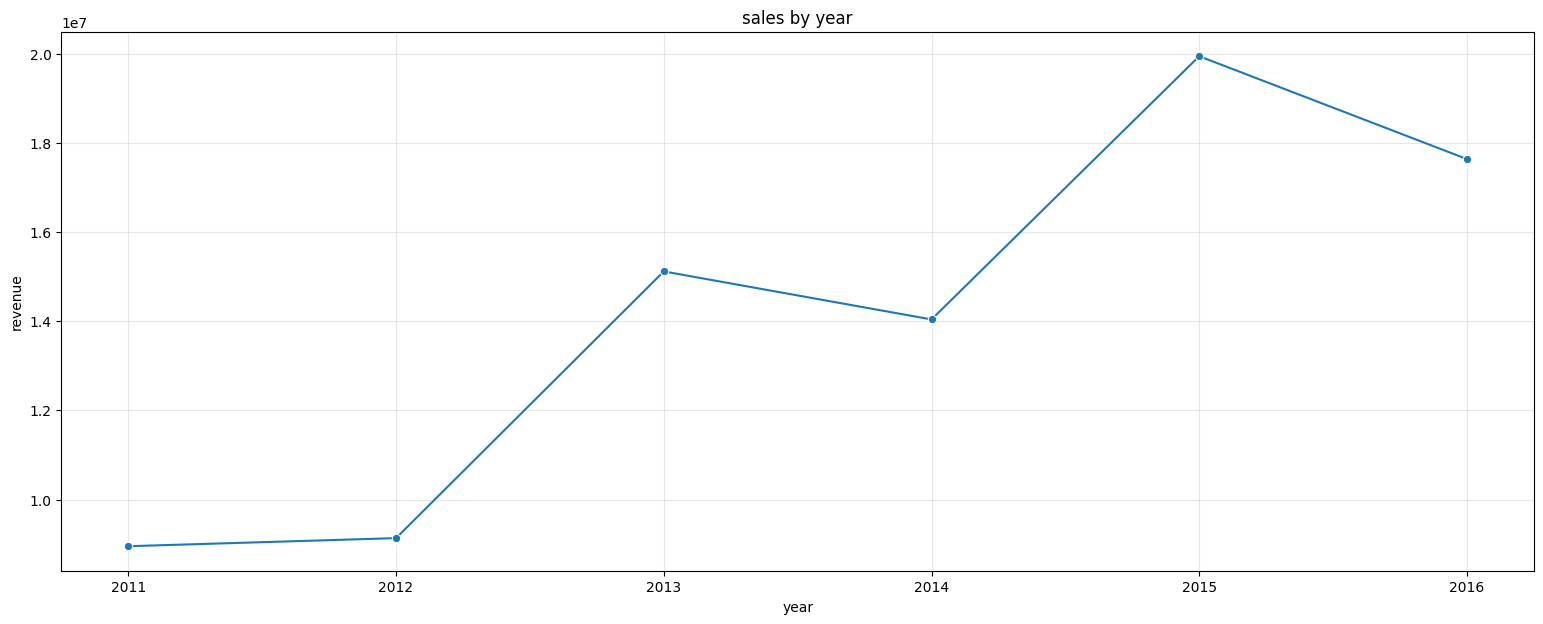

In [54]:
sales_by_year=df.groupby('year')['revenue'].sum().reset_index().sort_values(by='revenue',ascending=False)

plt.figure(figsize=(19,7))
sns.lineplot(data=sales_by_year,x='year',y='revenue',marker='o')

plt.title("sales by year")
plt.grid(alpha=0.3)
plt.show()

insights: year 2015 has generated highest sales

we can see there is growth in revenue over the years

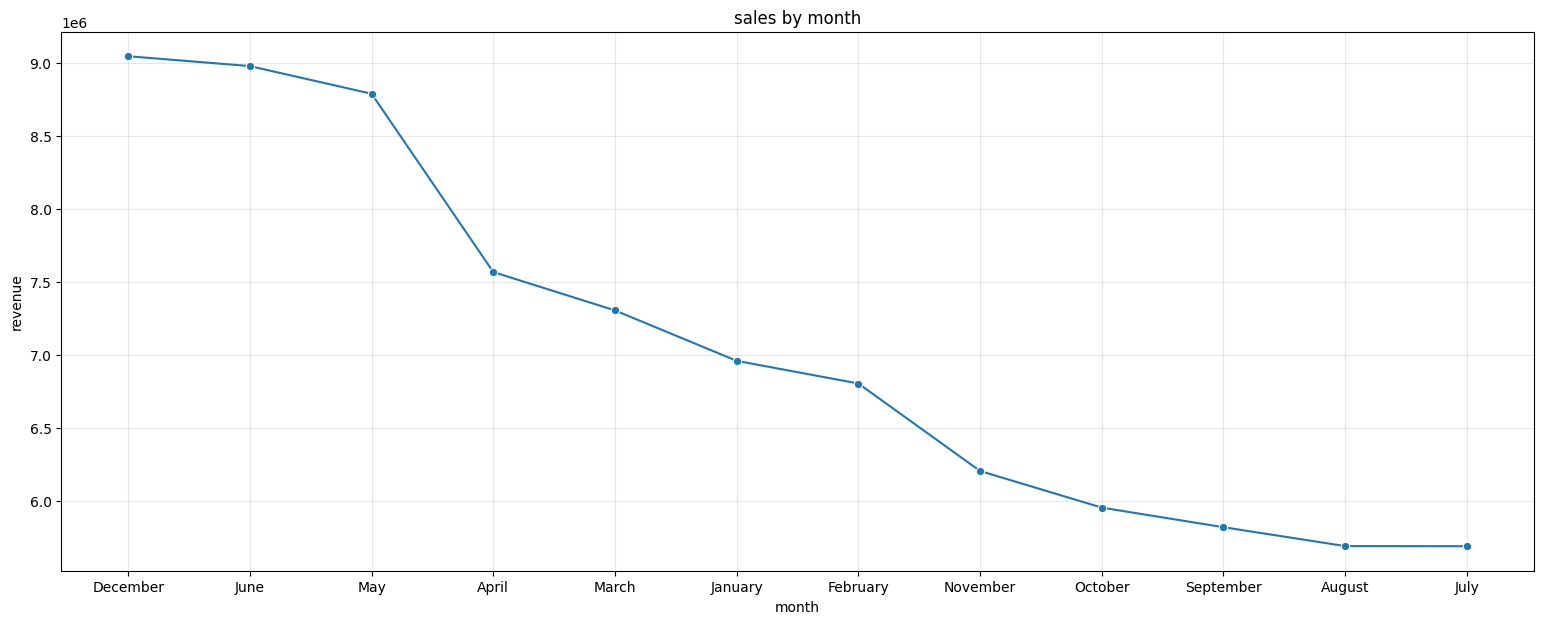

In [56]:
sales_by_month=df.groupby('month')['revenue'].sum().reset_index().sort_values(by='revenue',ascending=False)

plt.figure(figsize=(19,7))
sns.lineplot(data=sales_by_month,x='month',y='revenue',marker='o')

plt.title("sales by month")
plt.grid(alpha=0.3)
plt.show()

##### product category contributes the most to revenue

In [84]:
df.groupby('product_category')['revenue'].sum().reset_index()

,product_category,revenue
0,Accessories,15022766
1,Bikes,61434484
2,Clothing,8369522


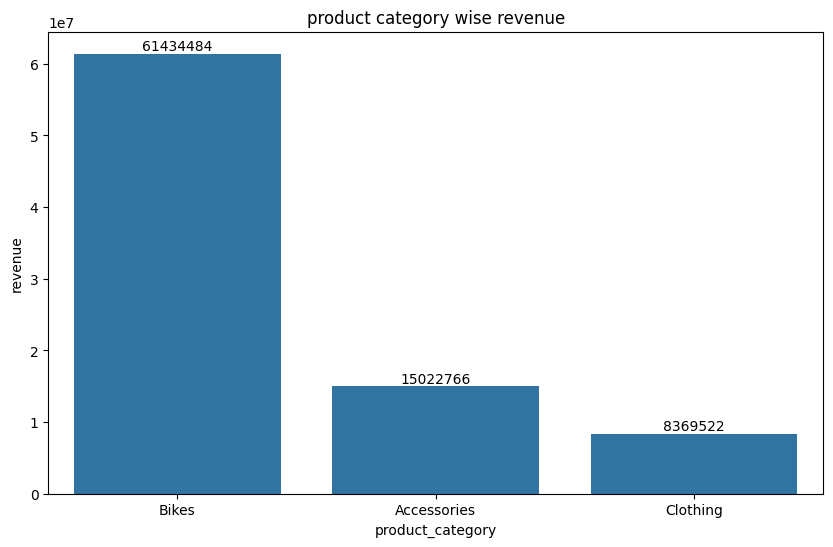

In [83]:
category_by_revenue=df.groupby('product_category')['revenue'].sum().reset_index().sort_values(by='revenue',ascending=False)

plt.figure(figsize=(10,6))
ax=sns.barplot(data=category_by_revenue,x='product_category',y='revenue')
for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("product category wise revenue")
plt.show()

insights: Bikes generate more revenue

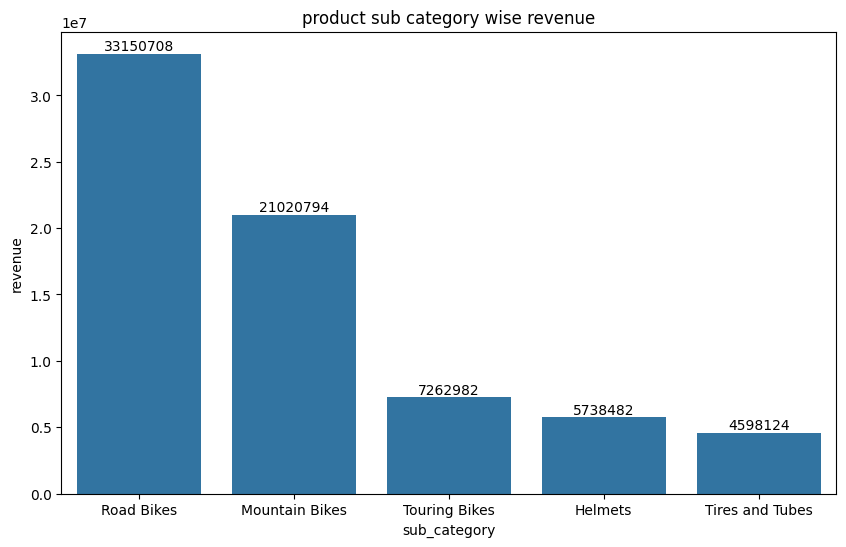

In [82]:
subcategory_by_revenue=df.groupby('sub_category')['revenue'].sum().reset_index().sort_values(by='revenue',ascending=False).head(5)

plt.figure(figsize=(10,6))
ax=sns.barplot(data=subcategory_by_revenue,x='sub_category',y='revenue')
for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("product sub category wise revenue")
plt.show()

##### Count of Age Group

In [68]:
df['age_group'].unique()

array(['Youth (<25)', 'Adults (35-64)', 'Young Adults (25-34)',
       'Seniors (64+)'], dtype=object)

In [69]:
df['age_group'].value_counts()

age_group
Adults (35-64)          55358
Young Adults (25-34)    38299
Youth (<25)             17660
Seniors (64+)             719
Name: count, dtype: int64

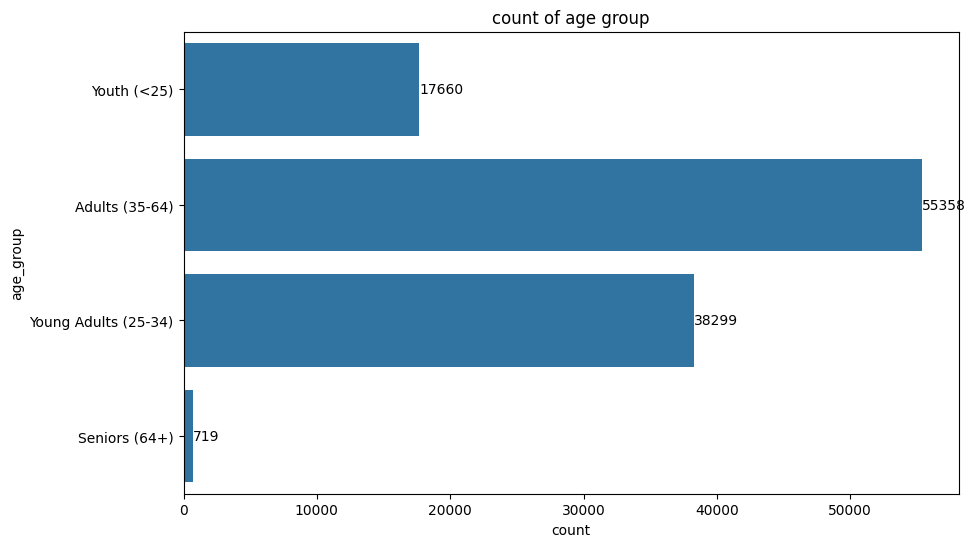

In [91]:
plt.figure(figsize=(10,6))
ax=sns.countplot(df['age_group'])

for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("count of age group")
plt.show()

#####   age group generates the most revenue

In [95]:
df.groupby('age_group')['revenue'].sum().reset_index()

,age_group,revenue
0,Adults (35-64),42367181
1,Seniors (64+),307070
2,Young Adults (25-34),30467032
3,Youth (<25),11685489


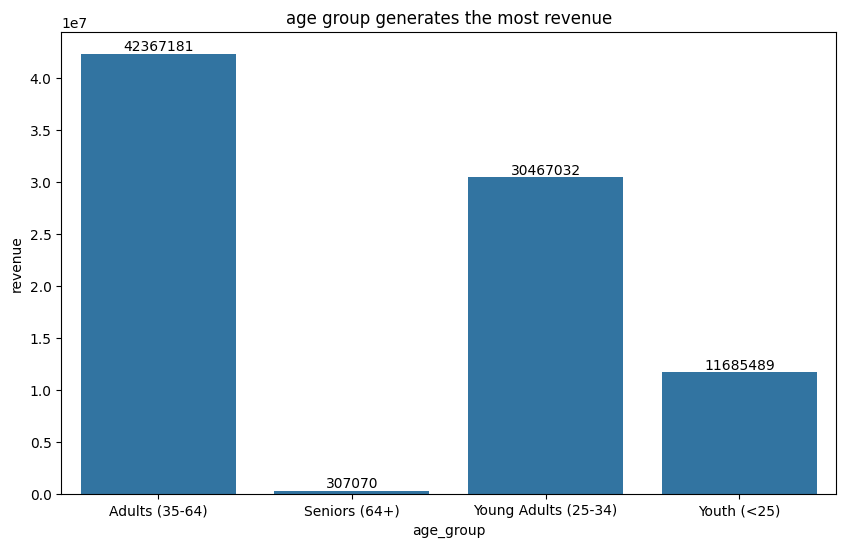

In [99]:
revenue_by_agegrp=df.groupby('age_group')['revenue'].sum().reset_index()

plt.figure(figsize=(10,6))
ax=sns.barplot(data=revenue_by_agegrp,x='age_group',y='revenue')
for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("age group generates the most revenue")
plt.show()

insights : From adults we get more revenue

##### Which age group is the most profitable

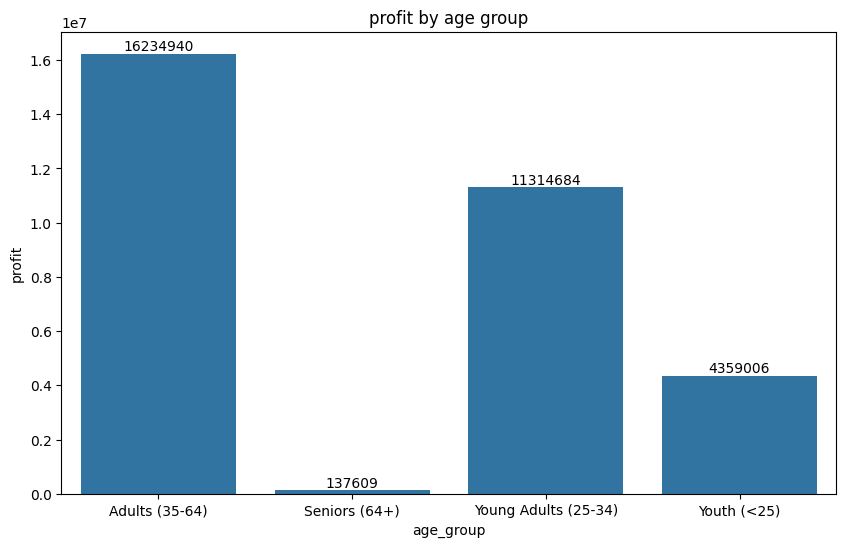

In [98]:
profit_by_agegrp=df.groupby('age_group')['profit'].sum().reset_index()

plt.figure(figsize=(10,6))
ax=sns.barplot(data=profit_by_agegrp,x='age_group',y='profit')
for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("profit by age group")
plt.show()

insights : through adults group we get more profit

##### Revenue by Gender

In [76]:
df['customer_gender'].value_counts()

customer_gender
M    57813
F    54223
Name: count, dtype: int64

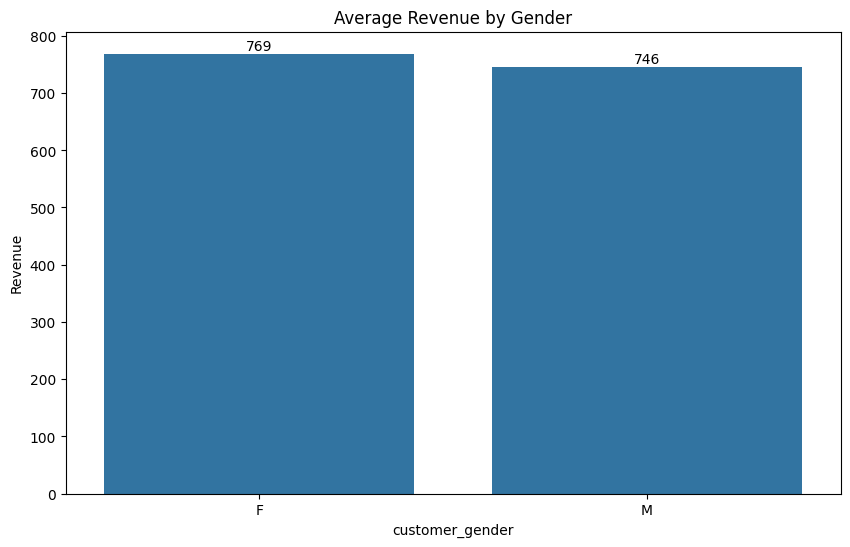

In [89]:

revenue_by_gender= df.groupby('customer_gender')['revenue'].mean().reset_index()

plt.figure(figsize=(10,6))
ax=sns.barplot(data=revenue_by_gender,x='customer_gender',y='revenue')
# add labels
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.0f')

plt.title("Average Revenue by Gender")
plt.ylabel("Revenue")
plt.show()

insights : Female customers spend slightly more on average than male customers

##### country generates the highest revenue

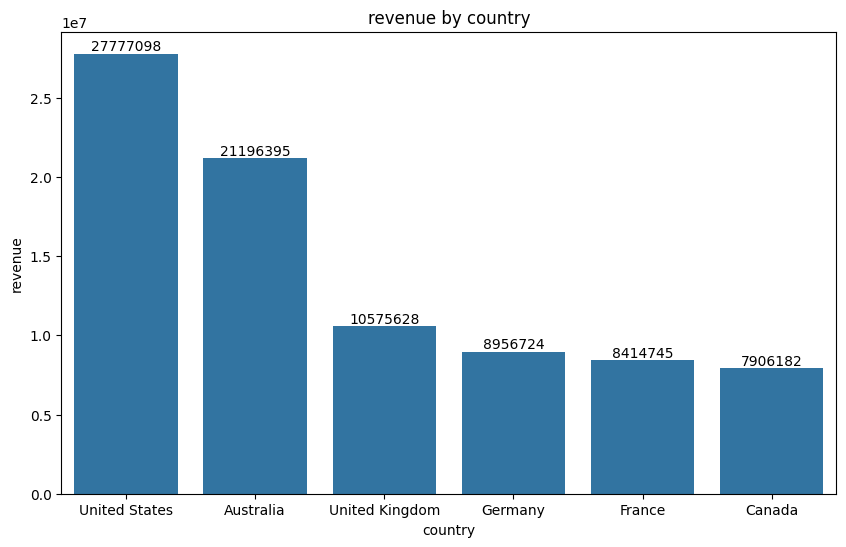

In [102]:
revenue_by_country=df.groupby('country')['revenue'].sum().reset_index().sort_values(by='revenue',ascending=False)

plt.figure(figsize=(10,6))
ax=sns.barplot(data=revenue_by_country,x='country',y='revenue')
for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("revenue by country")
plt.show()

insights: united states generates the highest revenue

##### Which state has the most sales

In [105]:
df.groupby('state')['revenue'].sum().reset_index().sort_values(by='revenue',ascending=False)

,state,revenue
6,California,17529787
8,England,10575628
26,New South Wales,9125980
5,British Columbia,7848334
50,Washington,6701258
35,Queensland,5055843
48,Victoria,5038294
33,Oregon,3435046
15,Hessen,2067980
36,Saarland,2026497


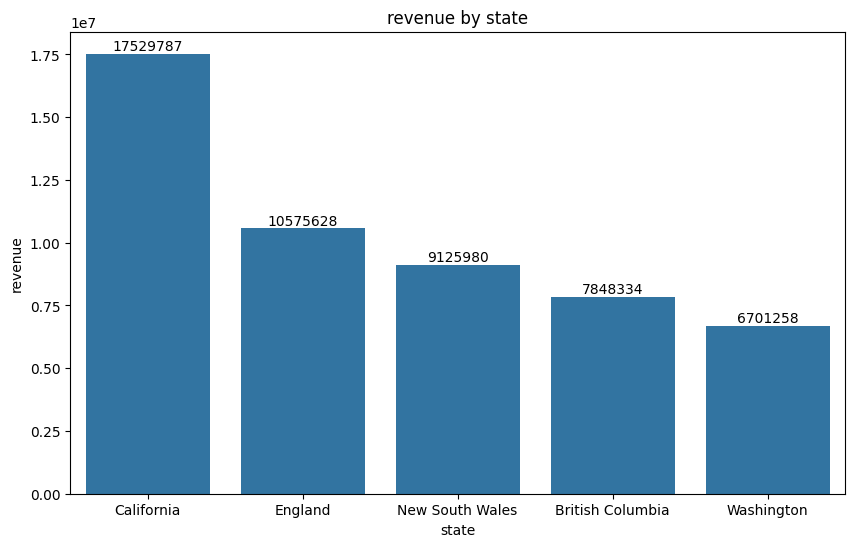

In [104]:
revenue_by_state=df.groupby('state')['revenue'].sum().reset_index().sort_values(by='revenue',ascending=False).head(5)

plt.figure(figsize=(10,6))
ax=sns.barplot(data=revenue_by_state,x='state',y='revenue')
for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("revenue by state")
plt.show()

insights : California has most sales

##### Which category gives the highest profit

In [110]:
df.groupby('product_category')['profit'].sum().reset_index().sort_values(by='profit',ascending=False)

,product_category,profit
1,Bikes,20399726
0,Accessories,8807194
2,Clothing,2839319


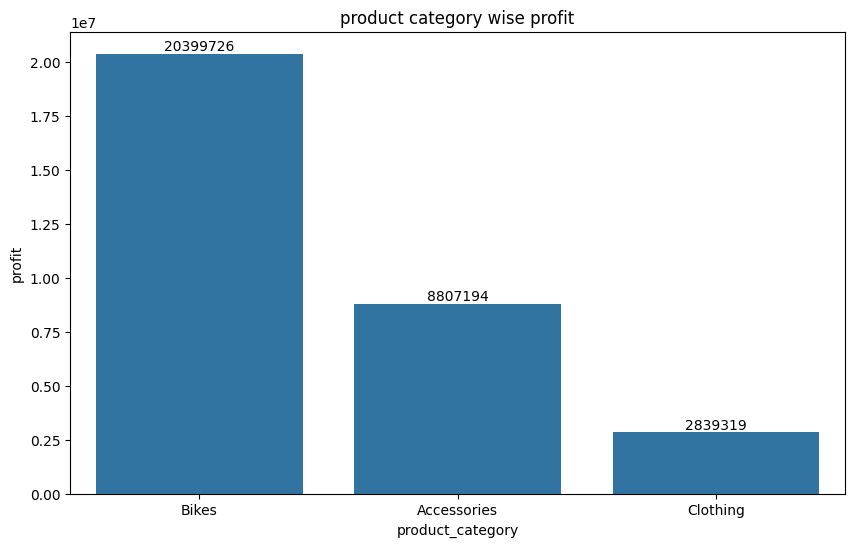

In [112]:
gb1=df.groupby('product_category')['profit'].sum().reset_index().sort_values(by='profit',ascending=False)

plt.figure(figsize=(10,6))
ax=sns.barplot(data=gb1,x='product_category',y='profit')
for bar in ax.containers: 
    ax.bar_label(bar, fmt='%.0f')
plt.title("product category wise profit")
plt.show()

insights: bikes give more profit

In [117]:
df.groupby('product_category')[['profit','revenue']].sum().reset_index().sort_values(by='revenue',ascending=False)

,product_category,profit,revenue
1,Bikes,20399726,61434484
0,Accessories,8807194,15022766
2,Clothing,2839319,8369522


insights: Bikes generate the highest revenue among all categories.

In [126]:
df[['profit','revenue','cost','unit_price','order_quantity']].corr()

,profit,revenue,cost,unit_price,order_quantity
profit,1.000000,0.956508,0.902109,0.749450,-0.238770
revenue,0.956508,1.000000,0.988748,0.818176,-0.312880
cost,0.902109,0.988748,1.000000,0.825965,-0.340386
unit_price,0.749450,0.818176,0.825965,1.000000,-0.516387
order_quantity,-0.238770,-0.312880,-0.340386,-0.516387,1.000000


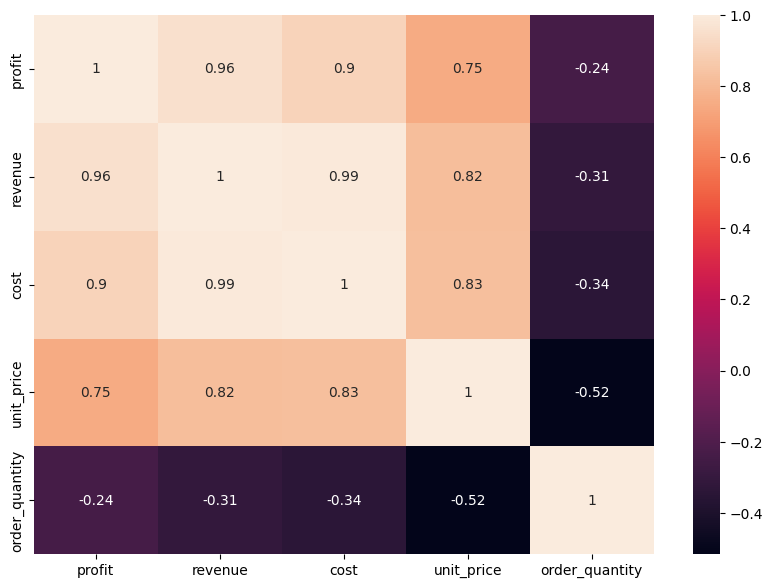

In [131]:
plt.figure(figsize=(10,7))
sns.heatmap(df[['profit','revenue','cost','unit_price','order_quantity']].corr(),annot=True)
plt.show()

insights:

Profit and revenue are highly positively correlated, meaning as revenue increases, profit also increases

Profit and cost show positive correlation because higher sales volume increases both revenue and cost simultaneously

Unit price has a strong positive correlation with profit(0.75), indicating that higher-priced products tend to generate more profit.

In [25]:
df.head(2)

,date,day,month,year,customer_age,age_group,customer_gender,country,state,product_category,sub_category,product,order_quantity,unit_cost,unit_price,profit,cost,revenue,roi
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,163.888889
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,163.888889
